In [4]:
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler
from langchain_ollama import ChatOllama

load_dotenv()

langfuse_trace = CallbackHandler()

In [ ]:
### Implementing chatbot using Langgraph
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
llm = ChatOllama(model="granite4")

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")
llm.invoke("Hello", config={"callbacks": [langfuse_trace]})

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_e3fcbabb13', 'id': 'chatcmpl-DuIOlmfNpM6OJ4jfrawIaJbMrkHH4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ef9ec-1c5f-7430-814a-84959bc18d8b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("Hey I am Tho and I like to play cricket", config={"callbacks": [langfuse_trace]})

AIMessage(content="Nice to meet you, Tho. Cricket is a fantastic sport, isn't it? Which role do you prefer to play in cricket - batsman, bowler, or all-rounder?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 46, 'total_tokens': 87, 'completion_time': 0.069430813, 'completion_tokens_details': None, 'prompt_time': 0.00323023, 'prompt_tokens_details': None, 'queue_time': 0.05366208, 'total_time': 0.072661043}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef9f1-15a0-7050-9f20-d90fd649352f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 41, 'total_tokens': 87})

In [10]:
### We will start with creating nodes

def superbot(state: State):
    return {"messages": llm_groq.invoke(state["messages"], config={'callbacks': [langfuse_trace]})}

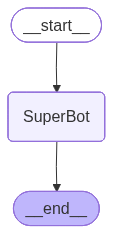

In [12]:
graph = StateGraph(State)

# Add node
graph.add_node("SuperBot", superbot)

# Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()

# Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
## Invocation

graph_builder.invoke(
    {"messages": "Hi, my name is Tho and I like cricket"},
    config={"callbacks": [langfuse_trace]}
)

{'messages': [HumanMessage(content='Hi, my name is Tho and I like cricket', additional_kwargs={}, response_metadata={}, id='a93d2a3e-c443-4779-80f4-6af50fcd86c8'),
  AIMessage(content='Nice to meet you, Tho. Cricket is a fantastic sport with a huge following worldwide. Which team or player is your favorite? Are you more into Test cricket, One-Day Internationals (ODIs), or the shorter format, Twenty20 (T20)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 46, 'total_tokens': 101, 'completion_time': 0.108137333, 'completion_tokens_details': None, 'prompt_time': 0.002797624, 'prompt_tokens_details': None, 'queue_time': 0.047015593, 'total_time': 0.110934957}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef9fd-0243-76e3-b224-436238c920e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

In [ ]:
## Streaming the responses
for event in graph_builder.stream(
    {"messages": "Hello My name is Tho"},
    config={"callbacks": [langfuse_trace]},
    stream_mode="values", ## This mode include all messages like HumanMessage, etc.
):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Tho', additional_kwargs={}, response_metadata={}, id='42e296df-89dd-4385-82ec-ca328d29c7ba')]}
{'messages': [HumanMessage(content='Hello My name is Tho', additional_kwargs={}, response_metadata={}, id='42e296df-89dd-4385-82ec-ca328d29c7ba'), AIMessage(content="Hello Tho, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.02705925, 'completion_tokens_details': None, 'prompt_time': 0.002442638, 'prompt_tokens_details': None, 'queue_time': 0.052930608, 'total_time': 0.029501888}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa01-71f7-7971-84ed-5ac0e98dbc0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata